# House Price Prediction using Linear Regression

**Name:** Shabab Zahra 

**CMS ID:** 023-24-0088

**Section:** D

**GitHub:** https://github.com/shababzahraa/Machine-Learning-Tasks

**Kaggle:** https://www.kaggle.com/shababzahra07

**Dataset:** House Prices - Advanced Regression Techniques  

**Dataset Source:** Kaggle

### Part 1 — Dataset, Problem & Feature/Target Identification
___

In [4]:
# 1.	Load the dataset and briefly inspect it (shape, dtypes, first few rows, summary statistics).
import pandas as pd 
df=pd.read_csv("train.csv")
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 Rows:\n", df.head())
print("\nSummary Statistics:\n", df.describe())

Shape: (1460, 81)

Data Types:
 Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object

First 5 Rows:
    Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN

In [5]:
#2.	Identify the dependent variable and list the independent variables,
#   split explicitly into numerical features and categorical features.
dependent_variable = 'SalePrice'
print("Dependent Variable: ", dependent_variable)

numerical_features = [
    'GrLivArea',
    'OverallQual',
    'TotalBsmtSF',
    'GarageCars',
    'YearBuilt',
    'FullBath',
    'GarageArea'
]
categorical_features = [
    'Neighborhood',
    'HouseStyle',
    'KitchenQual',
    'ExterQual'
]

print("\nNumerical Features\n", numerical_features)
print("\nCategorical Features\n", categorical_features)

Dependent Variable:  SalePrice

Numerical Features
 ['GrLivArea', 'OverallQual', 'TotalBsmtSF', 'GarageCars', 'YearBuilt', 'FullBath', 'GarageArea']

Categorical Features
 ['Neighborhood', 'HouseStyle', 'KitchenQual', 'ExterQual']


3.	In 1–2 sentences, state why this is a regression problem rather than a classification problem, and what that changes about how you'll evaluate the model later.

This is a regression problem because the target variable, SalePrice, is a continuous numerical value. Therefore, the model will be evaluated using regression metrics such as MAE, MSE, RMSE, and R² instead of classification metrics like accuracy, precision, and recall.

### Part 2 — Data Preparation & Train/Test Split
___

In [6]:
#4.	Prepare X (features) and y (price) for modeling: encode every categorical column into numeric form, 
# and briefly justify your choice of encoding method for each type of column.
x = df[numerical_features + categorical_features]
y = df[dependent_variable]

x = pd.get_dummies(x, columns=categorical_features, drop_first=True, dtype=int)

print("x\n", x.dtypes)
print("y\n", y)

x
 GrLivArea               int64
OverallQual             int64
TotalBsmtSF             int64
GarageCars              int64
YearBuilt               int64
FullBath                int64
GarageArea              int64
Neighborhood_Blueste    int64
Neighborhood_BrDale     int64
Neighborhood_BrkSide    int64
Neighborhood_ClearCr    int64
Neighborhood_CollgCr    int64
Neighborhood_Crawfor    int64
Neighborhood_Edwards    int64
Neighborhood_Gilbert    int64
Neighborhood_IDOTRR     int64
Neighborhood_MeadowV    int64
Neighborhood_Mitchel    int64
Neighborhood_NAmes      int64
Neighborhood_NPkVill    int64
Neighborhood_NWAmes     int64
Neighborhood_NoRidge    int64
Neighborhood_NridgHt    int64
Neighborhood_OldTown    int64
Neighborhood_SWISU      int64
Neighborhood_Sawyer     int64
Neighborhood_SawyerW    int64
Neighborhood_Somerst    int64
Neighborhood_StoneBr    int64
Neighborhood_Timber     int64
Neighborhood_Veenker    int64
HouseStyle_1.5Unf       int64
HouseStyle_1Story       int64
HouseSt

Numerical features are kept in their original numeric form because their values have meaningful numerical relationships. Categorical features are converted using One-Hot Encoding because their categories do not have a natural numerical order, and this prevents the model from assuming an artificial ranking between categories. drop_first=True is used to avoid redundant dummy variables.

In [7]:
#5.	Confirm X is fully numeric with no missing values.
print("Non Numeric Features")
print(x.select_dtypes(exclude=['number']).columns)
print("\nNumber of missing values")
print(x.isnull().sum().sum())

Non Numeric Features
Index([], dtype='object')

Number of missing values
0


In [8]:
#6.	Split X and y into training and test sets (e.g. an 80/20 split) and report the resulting shapes.
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42, test_size=0.2)
print("x Train Shape", x_train.shape)
print("x Test Shape", x_test.shape)
print("y Train Shape", y_train.shape)
print("y Test Shape", y_test.shape)

x Train Shape (1168, 44)
x Test Shape (292, 44)
y Train Shape (1168,)
y Test Shape (292,)


### Part 3 — Linear Regression & Predictions

In [9]:
#7.	Train a LinearRegression model on the training data.
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
#8.	Generate predicted prices on the test set, and display a small table comparing actual vs. predicted price for 10 test houses.
y_pred = lr_model.predict(x_test)
ActualPrice = y_test.iloc[:10].values
PredictedPrice = y_pred[:10]
print(ActualPrice, "\n")
print(PredictedPrice)


[154500 325000 115000 159000 315500  75500 311500 146000  84500 135500] 

[137005.97820333 323176.57673066 112131.58792659 171654.32760334
 306335.68314231  66829.28775308 230969.19533095 146860.71926647
  66394.14008189 116827.45967443]


| No | Actual Price | Predicted Price |
| --- | --- | --- |
| 1 | 154500 | 137005.978203 |
| 2 | 325000 | 323176.576731 |
| 3 | 115000 | 112131.587927 |
| 4 | 159000 | 171654.327603 |
| 5 | 315500 | 306335.683142 |
| 6 | 75500 | 66829.287753 |
| 7 | 311500 | 230969.195331 |
| 8 | 146000 | 146860.719266 |
| 9 | 84500 |	66394.140082 |
| 10 | 135500 | 116827.459674 |

#### Part 4 — Coefficients & Intercept
___

In [16]:
#9.	Extract the intercept and all coefficients. Build a table: Feature | Coefficient | Interpretation, with a one-line, 
# plain-English interpretation for each feature (e.g. "each additional bathroom is associated 
# with a price increase of approximately ___, holding other features constant").
print("Intercept:", lr_model.intercept_)

coefficient_table = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': lr_model.coef_
})

coefficient_table['Interpretation'] = coefficient_table.apply(
    lambda row: f"Each 1-unit increase in {row['Feature']} is associated with a price change of approximately {row['Coefficient']:.2f}, holding other features constant.",
    axis=1
)

pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 2000)

display(coefficient_table)

Intercept: -394050.54644877254


,Feature,Coefficient,Interpretation
0,GrLivArea,55.910480,"Each 1-unit increase in GrLivArea is associated with a price change of approximately 55.91, holding other features constant."
1,OverallQual,12545.035918,"Each 1-unit increase in OverallQual is associated with a price change of approximately 12545.04, holding other features constant."
2,TotalBsmtSF,4.506617,"Each 1-unit increase in TotalBsmtSF is associated with a price change of approximately 4.51, holding other features constant."
3,GarageCars,9806.297630,"Each 1-unit increase in GarageCars is associated with a price change of approximately 9806.30, holding other features constant."
4,YearBuilt,217.573836,"Each 1-unit increase in YearBuilt is associated with a price change of approximately 217.57, holding other features constant."
5,FullBath,-506.677739,"Each 1-unit increase in FullBath is associated with a price change of approximately -506.68, holding other features constant."
6,GarageArea,5.746063,"Each 1-unit increase in GarageArea is associated with a price change of approximately 5.75, holding other features constant."
7,Neighborhood_Blueste,-1341.660159,"Each 1-unit increase in Neighborhood_Blueste is associated with a price change of approximately -1341.66, holding other features constant."
8,Neighborhood_BrDale,-3748.994704,"Each 1-unit increase in Neighborhood_BrDale is associated with a price change of approximately -3748.99, holding other features constant."
9,Neighborhood_BrkSide,20195.257449,"Each 1-unit increase in Neighborhood_BrkSide is associated with a price change of approximately 20195.26, holding other features constant."


10.	Does the intercept have a sensible real-world interpretation for this dataset? Why or why not?

The intercept does not have a very sensible real-world interpretation for this dataset because it represents the predicted house price when all features are zero. A house with zero living area, zero bathrooms, zero garage capacity, etc. is not a realistic house in this dataset.

### Part 5 — Residuals & Regression Metrics
___

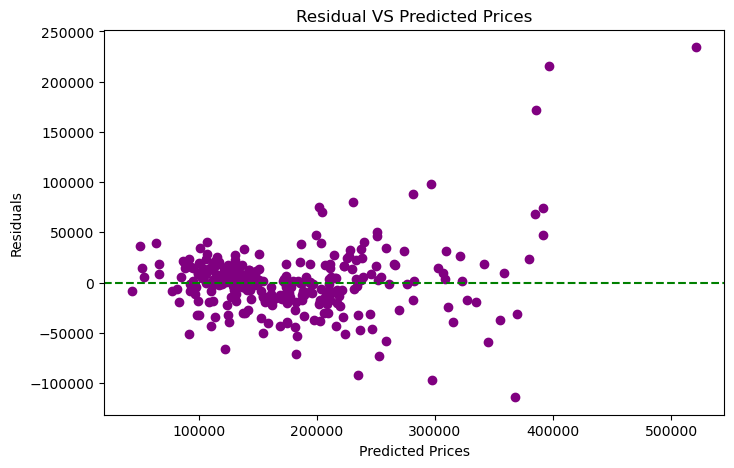

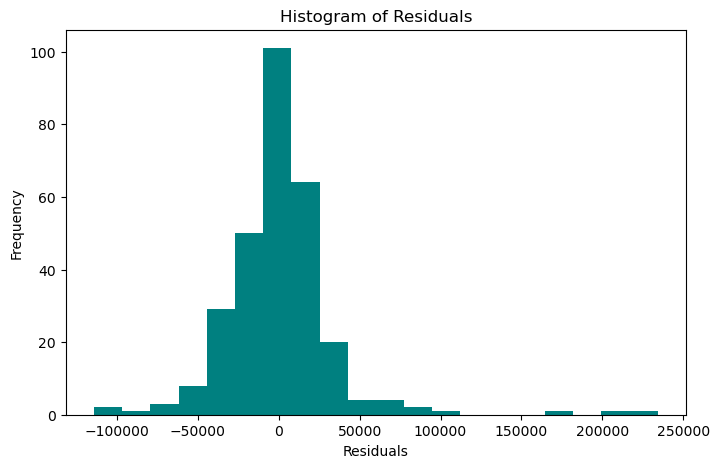

In [12]:
# 11.	Compute residuals on the test set and plot them (e.g. residuals vs. predicted values, and a histogram of residuals). 
# Do the residuals look randomly scattered, or is there a visible pattern?
residuals = y_test - y_pred

import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, color='purple')
plt.axhline(y=0, linestyle='--', color='green')
plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")
plt.title("Residual VS Predicted Prices")
plt.show()

plt.figure(figsize=(8,5))
plt.hist(residuals, bins=20, color='teal')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()


In [18]:
#12.	Compute MAE, MSE, RMSE, and R² on the test set. Report them in a small table.
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("MAE ", round(mae,4))
print("MSE ", round(mse,4))
print("RMSE ", round(rmse,4))
print("R2 Score ", round(r2,4))


MAE  21059.179
MSE  1175699284.3935
RMSE  34288.4716
R2 Score  0.8467


| Metric | Value |
|---|---:|
| MAE | 21059.179 |
| MSE | 1175699284.3935 |
| RMSE | 34288.4716 |
| R² | 0.8467 |

13.	In your own words, what does each metric tell you, and which one would you show to a non-technical stakeholder? Why?

**Interpretation of Evaluation Metrics**

- **MAE (Mean Absolute Error):** It tells us the average difference between the actual and predicted house prices. It is easy to understand because it is in the same units as the house price.

- **MSE (Mean Squared Error):** It measures the average squared error between actual and predicted prices. Larger errors have a bigger effect because the errors are squared.

- **RMSE (Root Mean Squared Error):** It shows the typical prediction error in the same units as the house price, while giving more importance to larger errors.

- **R² (R-squared):** It tells us how much of the variation in house prices is explained by the model. A higher R² means the model explains more of the variation.

**Metric for a Non-Technical Stakeholder**

I would show **MAE** to a non-technical stakeholder because it is easy to understand. It directly tells the average amount by which the predicted house price differs from the actual price.

### Part 6 — Training vs. Testing & Generalization
___

In [19]:
# 14.	Compute MAE, MSE, RMSE, and R² on the training set, and place them side by side with your Part 5 test-set metrics in one comparison table.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_train_pred = lr_model.predict(x_train)

train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

print('MAE ', round(train_mae,4))
print('MSE ', round(train_mse,4))
print('RMSE ', round(train_rmse,4))
print('R2 Score ', round(train_r2,4))

MAE  20419.3432
MSE  1043143424.6129
RMSE  32297.731
R2 Score  0.8251


**Training vs Test Set Metrics**

| Metric | Test  | Training
|---|---:| --- |
| MAE | 21059.179 | 20419.3432
| MSE | 1175699284.3935 | 1043143424.6129
| RMSE | 34288.4716 | 32297.731
| R² | 0.8467 |  0.8251

**Training vs Test Performance**

There is no large gap between the training and testing performance. The MAE and RMSE values are relatively close, while the R² values are also reasonably close.

A large gap between training and testing performance would suggest overfitting, meaning the model performs much better on training data than on unseen test data. A small gap generally indicates better generalization.

In our result, the training R² is 0.8251 and the test R² is 0.8467, while the training RMSE is 32297.73 and the test RMSE is 34288.47. These values are relatively close, so the model does not show a large overfitting gap and appears to generalize reasonably well to the test data.

### Part 7 — Final Model Analysis, Conclusion & Kaggle Submission
___

16.	Looking back at your Part 4 coefficient table, which 2–3 features appear most influential on price? Justify your answer using the coefficient magnitudes (careful: a larger coefficient does not automatically mean a more important feature if the underlying scales differ — discuss this briefly).

**Most Influential Features**

Based on the coefficient magnitudes, **OverallQual** and **GarageCars** appear to have a relatively strong effect on predicted house price. OverallQual has a coefficient of approximately **12545.04**, while GarageCars has a coefficient of approximately **9806.30**. GrLivArea has a coefficient of approximately **55.91**.

However, coefficient magnitude alone cannot be used to decide feature importance because the features have different scales and units. For example, GrLivArea is measured in square feet, while OverallQual is measured on a smaller rating scale. Therefore, a smaller coefficient does not necessarily mean that the feature is less important.

17.	Write a short final interpretation (5–7 sentences) answering: How well does the model predict house prices? Which metric is most useful and why? Which feature has the strongest effect? What limitations does Linear Regression have for this dataset? What would you try next?

**Final Interpretation**

The Linear Regression model predicts house prices reasonably well, with a test R² of 0.8467, meaning it explains about 84.67% of the variation in house prices. The MAE is 21,059.18, so the model's predictions differ from the actual prices by about $21,059 on average. MAE is the most useful metric for a non-technical stakeholder because it is easy to understand and is expressed in the same units as the house price. Among the selected features, OverallQual has the strongest coefficient magnitude at approximately 12,545.04, although coefficient magnitudes should be compared carefully because the features have different scales. Linear Regression has limitations because it assumes a linear relationship between the features and house prices and may not capture complex relationships or interactions between features. It can also be affected by outliers and multicollinearity among features. As a next step, I would try a more flexible model such as Random Forest or Gradient Boosting and compare its performance with Linear Regression.

In [ ]:
#18.	Apply the same feature selection and encoding you used on train.csv to test.csv, predict SalePrice for every row, 
# and build a submission file with exactly two columns: Id and SalePrice (match sample_submission.csv's format). Save it as submission.csv.
test_df = pd.read_csv("test.csv")

x_test_final = test_df[numerical_features + categorical_features]

x_test_final = pd.get_dummies(
    x_test_final,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

x_test_final = x_test_final.reindex(columns=x.columns, fill_value=0)

for col in numerical_features:
    x_test_final[col] = x_test_final[col].fillna(x_train[col].median())

test_predictions = lr_model.predict(x_test_final)

submission = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": test_predictions
})

submission.to_csv("submission.csv", index=False)

print(submission.head())


     Id      SalePrice
0  1461  114132.213786
1  1462  159782.241248
2  1463  163010.755168
3  1464  184233.508804
4  1465  249536.170527


19.	Submit submission.csv on the competition's "Submit Predictions" page. Record your public leaderboard score and rank, and write 1–2 sentences on how it felt to see your model measured against thousands of other real submissions.

### Competition Submission

- **Public Leaderboard Score:** 0.16582
- **Public Leaderboard Rank:** 2747

Seeing my model's predictions compared with thousands of other real submissions was exciting because it showed how my model performed in an actual competition. It also helped me understand that building a model is only the first step, and there is still room for improvement.